In [39]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

In [24]:
a = 1
b = 1
p = np.array([[1-a, a, 0, 0, 0], [b/4, 1- (3*a + b)/4, 3*a/4, 0, 0], [0, b/2, 1- (a+b)/2, a/2, 0], [0, 0, 3*b/4, 1 - (a+3*b)/4, a/4], [0, 0, 0, b, 1-b]])
q0 = np.array([1, 0, 0, 0, 0])
q50 = q0 @ np.linalg.matrix_power(p, 50)
q51 = q50 @ p
print(q50)
print(q51)

[0.125 0.    0.75  0.    0.125]
[0.  0.5 0.  0.5 0. ]


0.0
0.75


Text(0.5, 1.0, '$q_n(2)$ and $q_n(4)$ for n up to 60')

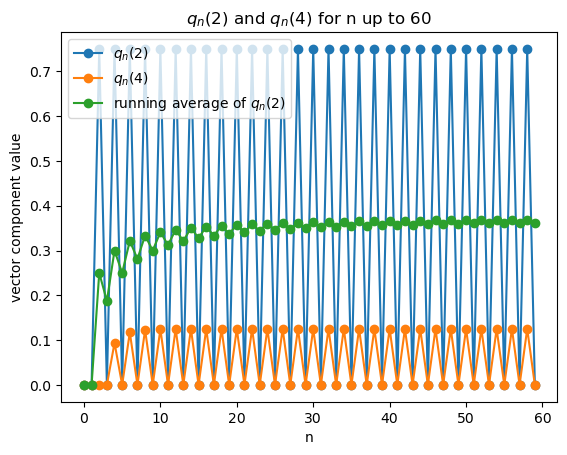

In [37]:
x = np.arange(60)
q2 = []
q4 = []
average = []
running_sum = 0
for i in range(60):
    qn = q0 @ np.linalg.matrix_power(p, i)
    q2.append(qn[2])
    q4.append(qn[4])
    if i == 0:
        average_new = qn[2]
        running_sum = qn[2]
    else:
        running_sum = running_sum + qn[2]
        average_new = 1/(i+1) * (running_sum)
    average.append(average_new)

plt.plot(x, q2, 'o-', label='$q_n(2)$')
print(q2[3])
print(q2[2])
plt.plot(x, q4, 'o-', label='$q_n(4)$')
plt.plot(x, average, 'o-', label='running average of $q_n(2)$')
plt.legend()
plt.xlabel('n')
plt.ylabel('vector component value')
plt.title('$q_n(2)$ and $q_n(4)$ for n up to 60')

## Part (c)

In [61]:
a = 0.3
b = 0.1
p2 = np.array([[1-a, a, 0, 0, 0], [b/4, 1- (3*a + b)/4, 3*a/4, 0, 0], [0, b/2, 1- (a+b)/2, a/2, 0], [0, 0, 3*b/4, 1 - (a+3*b)/4, a/4], [0, 0, 0, b, 1-b]])
A = p2.T - np.eye(5)
# enforce normalization - sum to 1
A[-1, :] = [1,1,1,1,1]

rhs = np.array([0,0,0,0,1])

pi = np.linalg.solve(A, rhs)
print(pi)

theta = a/(a+b)
pi_true = sc.stats.binom.pmf(np.arange(5), 4, theta)
print(pi_true)


[0.00390625 0.046875   0.2109375  0.421875   0.31640625]
[0.00390625 0.046875   0.2109375  0.421875   0.31640625]


In [60]:
q_old = np.array([1,0,0,0,0])
count = 0
for n in range(1, 100000000):
    q_new = q_old @ p2
    if np.max(np.abs(q_new - pi_true)) < 1e-6:
        count = n
        break
    q_old = q_new
print(count)

eigenvalues, _ = np.linalg.eig(p)
print(eigenvalues)

134
[0.6 0.7 0.8 0.9 1. ]
